In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

workflow_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes"
output_dir = workflow_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

splits_rerank = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]

split_labels = {
    "training14b_10pct_sample": "dev",
    "13B1_golden": "13B1",
    "13B2_golden": "13B2",
    "13B3_golden": "13B3",
    "13B4_golden": "13B4",
}

map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {
            _extract_pmid(d)
            for d in docs
            if _extract_pmid(d)
        }
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs: list[str], rels: set[str], k: int) -> float:
    """BioASQ-style AP@k, matching retrieval_eval.common.ap_at_k."""
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _map_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


qrels_paths = {
    "training14b_10pct_sample": base_dir / "example" / "training14b_10pct_sample.json",
    "13B1_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
}

qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}

# Precompute overlapping qids between train and test splits based on rerank runs
train_split_id = "training14b_10pct_sample"
test_split_ids = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

rerank_only_run_dirs = {
    "MiniLM": base_dir / "output" / "eval_stage2_rerank_miniLM" / "runs",
}

train_overlap_qids: set[str] = set()

minilm_runs_dir = rerank_only_run_dirs["MiniLM"]

train_candidates = list(minilm_runs_dir.glob("best_rrf_train_subset_top*.tsv"))
if train_candidates:
    train_run_df = _load_run(train_candidates[0])
    train_qid_col, _ = train_run_df.columns.tolist()
    train_qids_run = set(train_run_df[train_qid_col].astype(str).tolist())
else:
    train_qids_run = set()

test_qids_run: set[str] = set()
for s in test_split_ids:
    test_candidates = list(minilm_runs_dir.glob(f"best_rrf_{s}_top*.tsv"))
    if not test_candidates:
        continue
    test_run_df = _load_run(test_candidates[0])
    qid_col, _ = test_run_df.columns.tolist()
    test_qids_run.update(test_run_df[qid_col].astype(str).tolist())

train_overlap_qids = train_qids_run & test_qids_run

## 10. Reranker Top-1 Overlap, Win/Loss, and Jaccard@10

In [4]:
# Methods and runs for pairwise comparison (ignore BGE len=200)
pair_methods = {
    "MiniLM": base_dir / "output" / "eval_stage2_rerank_miniLM" / "runs",
    "BGE-m3": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len512" / "runs",
    "Gemma 2.5B": base_dir / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
}

splits_pairs = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]

# Reuse the same train/test overlap set so that train-only tables exclude
# any queries whose IDs also appear in the test batches.
pair_train_overlap_qids = train_overlap_qids

# Collect top-1 and top-10 docs per (method, split, qid)
top1_docs: dict[str, dict[tuple[str, str], str | None]] = {m: {} for m in pair_methods}
top10_docs: dict[str, dict[tuple[str, str], list[str]]] = {m: {} for m in pair_methods}

for split in splits_pairs:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in pair_methods.items():
        # Train/dev filenames use different stems ("train_subset" vs "training14b_10pct_sample")
        stems = [split]
        if split == "training14b_10pct_sample":
            stems = ["train_subset", split]

        run_path = None
        for stem in stems:
            pattern = f"best_rrf_{stem}_top"
            candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
            if candidates:
                run_path = candidates[0]
                break

        if run_path is None:
            continue

        run_df = _load_run(run_path)
        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            qid_str = str(qid)
            if split == "training14b_10pct_sample" and pair_train_overlap_qids and qid_str in pair_train_overlap_qids:
                continue
            key = (split, qid_str)
            docs = group[doc_col].astype(str).tolist()
            top1_docs[method_name][key] = docs[0] if docs else None
            top10_docs[method_name][key] = docs[:10]

# All query keys where at least one method has output
all_keys: set[tuple[str, str]] = set()
for m in pair_methods:
    all_keys.update(top1_docs[m].keys())

# Use all keys (train overlap qids were already excluded when building top1_docs/top10_docs).
analysis_keys = all_keys

method_pairs = [
    ("MiniLM", "BGE-m3"),
    ("MiniLM", "Gemma 2.5B"),
    ("BGE-m3", "Gemma 2.5B"),
]

# 1. Top-1 overlap counts
rows_overlap = []
for a, b in method_pairs:
    same = 0
    different = 0
    total = 0
    for split, qid in analysis_keys:
        a_doc = top1_docs[a].get((split, qid))
        b_doc = top1_docs[b].get((split, qid))
        if not a_doc or not b_doc:
            continue
        total += 1
        if a_doc == b_doc:
            same += 1
        else:
            different += 1
    rows_overlap.append(
        {
            "pair": f"{a} vs {b}",
            "same_top1": same,
            "different_top1": different,
            "total_queries": total,
            "same_frac": same / total if total else 0.0,
        }
    )

df_overlap = pd.DataFrame(rows_overlap)
print("Top-1 overlap (MiniLM, BGE-m3 len512, Gemma):")
print(df_overlap.round(3).to_string(index=False))

overlap_path = output_dir / "08_reranker_top1_overlap.csv"
df_overlap.to_csv(overlap_path, index=False)
print("Saved:", overlap_path)

# 2. Top-1 win/loss vs relevance
rows_winloss = []
for a, b in method_pairs:
    a_rel_b_not = 0
    b_rel_a_not = 0
    both_rel = 0
    neither_rel = 0
    total = 0
    for split, qid in analysis_keys:
        a_doc = top1_docs[a].get((split, qid))
        b_doc = top1_docs[b].get((split, qid))
        if not a_doc or not b_doc:
            continue
        rels = qrels_by_split.get(split, {}).get(qid, set())
        if not rels:
            continue
        a_is_rel = a_doc in rels
        b_is_rel = b_doc in rels
        total += 1
        if a_is_rel and not b_is_rel:
            a_rel_b_not += 1
        elif b_is_rel and not a_is_rel:
            b_rel_a_not += 1
        elif a_is_rel and b_is_rel:
            both_rel += 1
        else:
            neither_rel += 1

    rows_winloss.append(
        {
            "pair": f"{a} vs {b}",
            "A_name": a,
            "B_name": b,
            "A_win": a_rel_b_not,
            "B_win": b_rel_a_not,
            "both_rel": both_rel,
            "neither_rel": neither_rel,
            "total_queries": total,
            "A_win_frac": a_rel_b_not / total if total else float("nan"),
            "B_win_frac": b_rel_a_not / total if total else float("nan"),
            "both_rel_frac": both_rel / total if total else float("nan"),
            "neither_rel_frac": neither_rel / total if total else float("nan"),
        }
    )

df_winloss = pd.DataFrame(rows_winloss)
print("\nTop-1 win/loss vs relevance (standardized table):")
print(df_winloss.round(3).to_string(index=False))

winloss_path = output_dir / "09_reranker_top1_winloss.csv"
df_winloss.to_csv(winloss_path, index=False)
print("Saved:", winloss_path)

# 3. Jaccard overlap of top-10 sets
rows_jaccard = []
for a, b in method_pairs:
    jaccs = []
    n_pairs = 0
    for split, qid in analysis_keys:
        a_docs = top10_docs[a].get((split, qid))
        b_docs = top10_docs[b].get((split, qid))
        if not a_docs or not b_docs:
            continue
        set_a = set(a_docs)
        set_b = set(b_docs)
        union = set_a | set_b
        if not union:
            continue
        inter = set_a & set_b
        j = len(inter) / len(union)
        jaccs.append(j)
        n_pairs += 1
    mean_j = float(np.mean(jaccs)) if jaccs else 0.0
    median_j = float(np.median(jaccs)) if jaccs else 0.0
    rows_jaccard.append(
        {
            "pair": f"{a} vs {b}",
            "mean_jaccard@10": mean_j,
            "median_jaccard@10": median_j,
            "n_queries": n_pairs,
        }
    )

df_jacc = pd.DataFrame(rows_jaccard)
print("\nJaccard overlap of top-10 (MiniLM, BGE-m3 len512, Gemma):")
print(df_jacc.round(3).to_string(index=False))

jacc_path = output_dir / "10_reranker_jaccard_top10.csv"
df_jacc.to_csv(jacc_path, index=False)
print("Saved:", jacc_path)

Top-1 overlap (MiniLM, BGE-m3 len512, Gemma):
                pair  same_top1  different_top1  total_queries  same_frac
    MiniLM vs BGE-m3        337             586            923      0.365
MiniLM vs Gemma 2.5B        307             616            923      0.333
BGE-m3 vs Gemma 2.5B        374             549            923      0.405
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/08_reranker_top1_overlap.csv

Top-1 win/loss vs relevance (standardized table):
                pair A_name     B_name  A_win  B_win  both_rel  neither_rel  total_queries  A_win_frac  B_win_frac  both_rel_frac  neither_rel_frac
    MiniLM vs BGE-m3 MiniLM     BGE-m3    107     99       299          418            923       0.116       0.107          0.324             0.453
MiniLM vs Gemma 2.5B MiniLM Gemma 2.5B     89    150       317          367            923       0.096       0.163          0.343             0.398
BGE-m3 vs Gemma 2.5B BGE-m3 Gemma 2.5B     69  

## 11. RRF fusion sweep: MiniLM + BGE-m3 (keep Gemma on plot)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/11_rrf_fusion_minilm_bge_m3_mapk.png


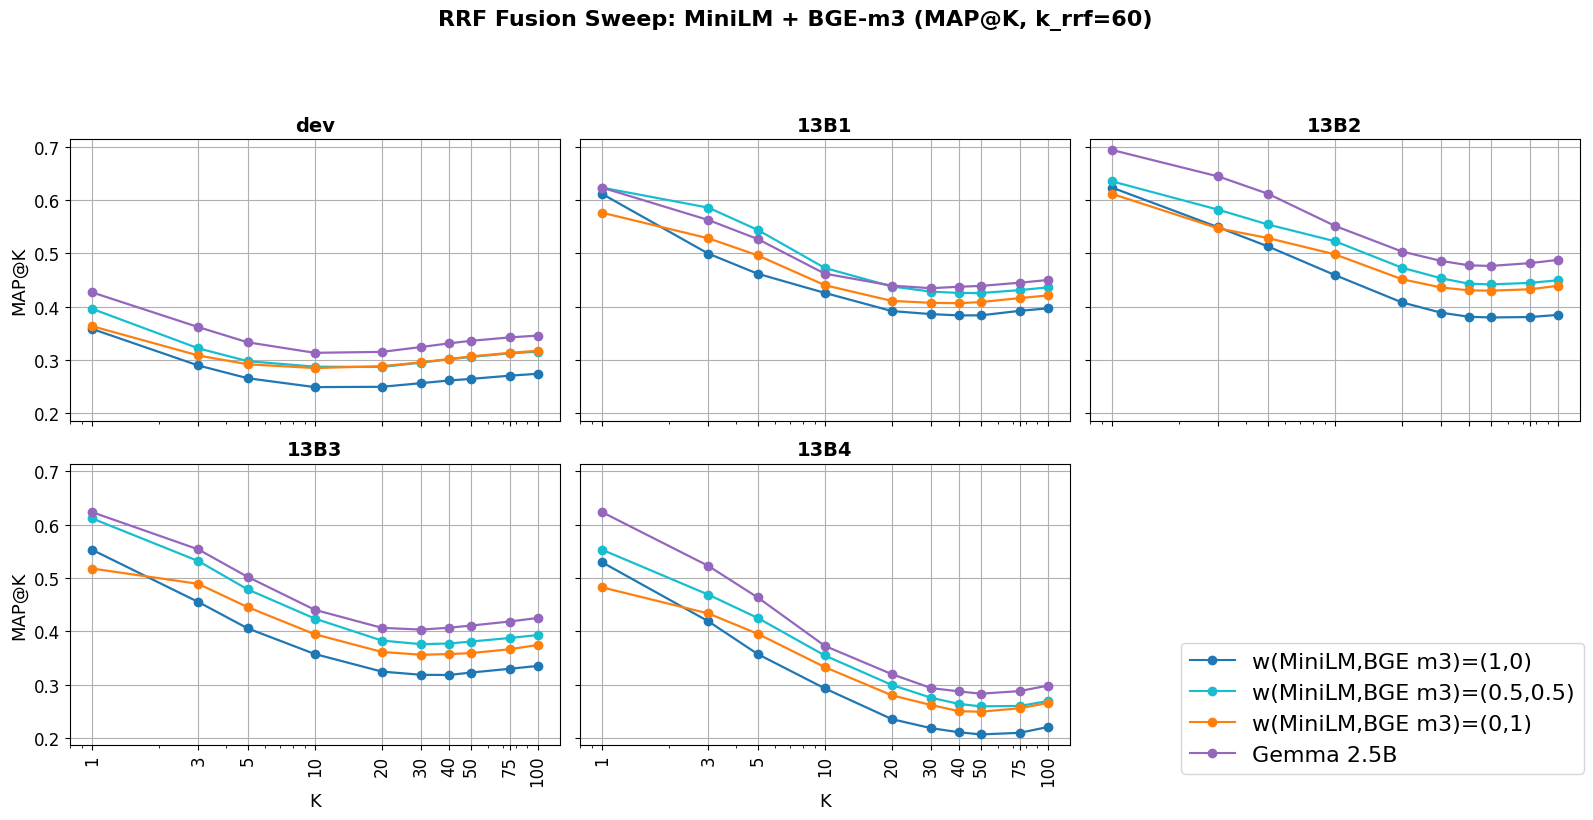

In [5]:
from collections import defaultdict

rrf_k = 60
fusion_pool_top = 100  # truncation for each reranker; set None to use full lists
fusion_weights = [
    (0.0, 1.0),
   # (0.33, 0.67),
    (0.5, 0.5),
    #(0.67, 0.33),
    (1.0, 0.0),
]

fusion_labels = {
    (0.0, 1.0): "w(MiniLM,BGE m3)=(0,1)",
    #(0.33, 0.67): "w(MiniLM,BGE)=(0.33,0.67)",
    (0.5, 0.5): "w(MiniLM,BGE m3)=(0.5,0.5)",
    #(0.67, 0.33): "w(MiniLM,BGE)=(0.67,0.33)",
    (1.0, 0.0): "w(MiniLM,BGE m3)=(1,0)",
}

minilm_runs_dir = base_dir / "output" / "eval_stage2_rerank_miniLM" / "runs"
bge_runs_dir = base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len512" / "runs"
gemma_runs_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs"

def _find_run_path(runs_dir: Path, split: str) -> Path | None:
    # Train/dev split uses both "train_subset" and "training14b_10pct_sample"
    stems = [split]
    if split == "training14b_10pct_sample":
        stems = ["train_subset", split]
    for stem in stems:
        cands = list(runs_dir.glob(f"best_rrf_{stem}_top*.tsv"))
        if cands:
            return cands[0]
    return None

def _rrf_fuse_two_lists(
    docs_a: list[str],
    docs_b: list[str],
    pool_a: int,
    pool_b: int,
    k_rrf: int,
    w_a: float,
    w_b: float,
) -> list[str]:
    # Adapted from rerank_rrf_hybrid._rrf_fuse_docs
    a_top = docs_a[:pool_a]
    b_top = docs_b[:pool_b]
    rank_a = {d: i + 1 for i, d in enumerate(a_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    union = list(dict.fromkeys(a_top + b_top))
    scored = []
    for d in union:
        s = 0.0
        ra = rank_a.get(d)
        rb = rank_b.get(d)
        if ra is not None:
            s += w_a / (k_rrf + ra)
        if rb is not None:
            s += w_b / (k_rrf + rb)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]

# Build MAP@K curves for: MiniLM, BGE-m3, Gemma, and each fusion weight
fusion_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    # Load base runs
    minilm_path = _find_run_path(minilm_runs_dir, split)
    bge_path = _find_run_path(bge_runs_dir, split)
    gemma_path = _find_run_path(gemma_runs_dir, split)

    if not minilm_path or not bge_path:
        continue  # need both for fusion

    minilm_df = _load_run(minilm_path)
    bge_df = _load_run(bge_path)

    # Optional: apply same train-overlap filtering as section 9
    if split == "training14b_10pct_sample" and train_overlap_qids:
        qid_col, _ = minilm_df.columns.tolist()
        mask = ~minilm_df[qid_col].astype(str).isin(train_overlap_qids)
        minilm_df = minilm_df[mask]
        mask = ~bge_df[qid_col].astype(str).isin(train_overlap_qids)
        bge_df = bge_df[mask]

    # Build per-qid doc lists
    qid_col, doc_col = minilm_df.columns.tolist()
    minilm_docs = {
        q: g[doc_col].astype(str).tolist()
        for q, g in minilm_df.groupby(qid_col, sort=False)
    }
    bge_docs = {
        q: g[doc_col].astype(str).tolist()
        for q, g in bge_df.groupby(qid_col, sort=False)
    }

    # 1) Base curve for Gemma only (MiniLM/BGE endpoints are covered by fusion weights)
    if gemma_path:
        gemma_df = _load_run(gemma_path)
        if split == "training14b_10pct_sample" and train_overlap_qids:
            qid_col, _ = gemma_df.columns.tolist()
            gemma_df = gemma_df[~gemma_df[qid_col].astype(str).isin(train_overlap_qids)]
        fusion_curves["Gemma 2.5B"][split] = _map_at_ks_for_run(gemma_df, qrels_split, map_ks)

    # 2) Fusion curves for each weight pair
    union_qids = sorted(set(minilm_docs.keys()) | set(bge_docs.keys()), key=str)
    for w_a, w_b in fusion_weights:
        label = fusion_labels[(w_a, w_b)]
        rows = []
        for qid in union_qids:
            docs_a = minilm_docs.get(qid, [])
            docs_b = bge_docs.get(qid, [])
            if fusion_pool_top is None:
                pool_a = len(docs_a) if docs_a else 0
                pool_b = len(docs_b) if docs_b else 0
            else:
                pool_a = min(fusion_pool_top, len(docs_a)) if docs_a else 0
                pool_b = min(fusion_pool_top, len(docs_b)) if docs_b else 0

            fused = _rrf_fuse_two_lists(
                docs_a,
                docs_b,
                pool_a=pool_a,
                pool_b=pool_b,
                k_rrf=rrf_k,
                w_a=w_a,
                w_b=w_b,
            )
            for rank, doc in enumerate(fused, start=1):
                rows.append((str(qid), doc))
        if not rows:
            continue
        fused_df = pd.DataFrame(rows, columns=["qid", doc_col])
        if split == "training14b_10pct_sample" and train_overlap_qids:
            fused_df = fused_df[~fused_df["qid"].astype(str).isin(train_overlap_qids)]
        fusion_curves[label][split] = _map_at_ks_for_run(fused_df, qrels_split, map_ks)

# Plot: 2x3 grid, one panel per split (train + 4 tests), lines for base + fusions
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

series_order = [
    "w(MiniLM,BGE m3)=(1,0)",
   # "w(MiniLM,BGE)=(0.67,0.33)",
    "w(MiniLM,BGE m3)=(0.5,0.5)",
   # "w(MiniLM,BGE)=(0.33,0.67)",
    "w(MiniLM,BGE m3)=(0,1)",
    "Gemma 2.5B",
]

colors_fusion = {
    "w(MiniLM,BGE m3)=(1,0)": "#1f77b4",
    #"w(MiniLM,BGE)=(0.67,0.33)": "#2ca02c",
    "w(MiniLM,BGE m3)=(0.5,0.5)": "#17becf",
    #"w(MiniLM,BGE)=(0.33,0.67)": "#8c564b",
    "w(MiniLM,BGE m3)=(0,1)": "#ff7f0e",
    "Gemma 2.5B": "#9467bd",
}

# y-range
all_vals = []
for name in series_order:
    for split_vals in fusion_curves.get(name, {}).values():
        all_vals.extend(split_vals.values())
y_min = max(0.0, min(all_vals) - 0.02) if all_vals else 0.0
y_max = min(1.0, max(all_vals) + 0.02) if all_vals else 1.0

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for name in series_order:
        split_map = fusion_curves.get(name, {}).get(split)
        if not split_map:
            continue
        ys = [split_map.get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            ys,
            marker="o",
            linewidth=1.6,
            color=colors_fusion.get(name, "#999999"),
            label=name,
        )
    ax.set_xscale("log")
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)

# Hide unused 6th panel if any
for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].set_visible(False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=colors_fusion[name], marker="o", linestyle="-", label=name)
    for name in series_order
]
fig.legend(
    handles=legend_handles,
    labels=series_order,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.05),
    fontsize=16,
)

fig.suptitle("RRF Fusion Sweep: MiniLM + BGE-m3 (MAP@K, k_rrf=60)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "11_rrf_fusion_minilm_bge_m3_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 12. Three-way RRF Fusion Sweep: MiniLM + BGE-m3 + Gemma

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/12_rrf_fusion_minilm_bge_m3_gemma_mapk.png


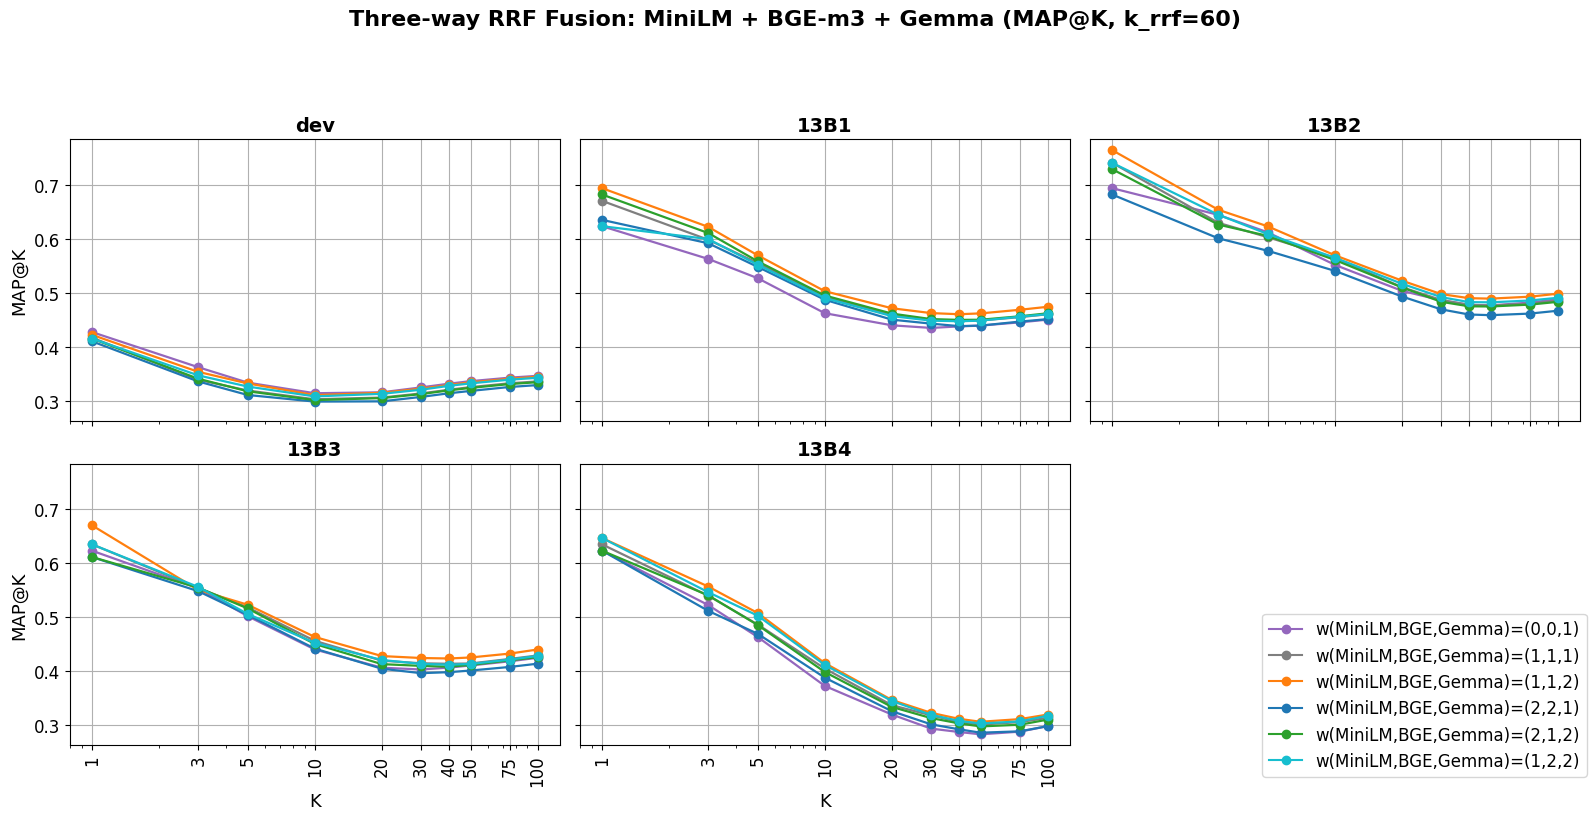

In [6]:
# We now extend the RRF fusion to three rerankers simultaneously:
# MiniLM, BGE-m3 len512, and Gemma 2.5B.

fusion3_weights = [
    (0.0, 0.0, 1.0),  # Gemma only
    (1.0, 1.0, 1.0),  # equal weights
    (1.0, 1.0, 2.0),  # Gemma emphasis
    (2.0, 2.0, 1.0),  # MiniLM+BGE emphasis
    (2.0, 1.0, 2.0),  # MiniLM+Gemma emphasis
    (1.0, 2.0, 2.0),  # BGE+Gemma emphasis
]

fusion3_labels = {
    (0.0, 0.0, 1.0): "w(MiniLM,BGE,Gemma)=(0,0,1)",
    (1.0, 1.0, 1.0): "w(MiniLM,BGE,Gemma)=(1,1,1)",
    (1.0, 1.0, 2.0): "w(MiniLM,BGE,Gemma)=(1,1,2)",
    (2.0, 2.0, 1.0): "w(MiniLM,BGE,Gemma)=(2,2,1)",
    (2.0, 1.0, 2.0): "w(MiniLM,BGE,Gemma)=(2,1,2)",
    (1.0, 2.0, 2.0): "w(MiniLM,BGE,Gemma)=(1,2,2)",
}


def _rrf_fuse_three_lists(
    docs_m: list[str],
    docs_b: list[str],
    docs_g: list[str],
    pool_m: int,
    pool_b: int,
    pool_g: int,
    k_rrf: int,
    w_m: float,
    w_b: float,
    w_g: float,
) -> list[str]:
    """Three-way weighted RRF fusion of MiniLM, BGE, and Gemma doc lists."""
    m_top = docs_m[:pool_m]
    b_top = docs_b[:pool_b]
    g_top = docs_g[:pool_g]
    rank_m = {d: i + 1 for i, d in enumerate(m_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    rank_g = {d: i + 1 for i, d in enumerate(g_top)}
    union = list(dict.fromkeys(m_top + b_top + g_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        rm = rank_m.get(d)
        rb = rank_b.get(d)
        rg = rank_g.get(d)
        if rm is not None:
            s += w_m / (k_rrf + rm)
        if rb is not None:
            s += w_b / (k_rrf + rb)
        if rg is not None:
            s += w_g / (k_rrf + rg)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


fusion3_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    minilm_path = _find_run_path(minilm_runs_dir, split)
    bge_path = _find_run_path(bge_runs_dir, split)
    gemma_path = _find_run_path(gemma_runs_dir, split)
    if not (minilm_path and bge_path and gemma_path):
        continue

    minilm_df = _load_run(minilm_path)
    bge_df = _load_run(bge_path)
    gemma_df = _load_run(gemma_path)

    if split == "training14b_10pct_sample" and train_overlap_qids:
        qid_col, _ = minilm_df.columns.tolist()
        mask = ~minilm_df[qid_col].astype(str).isin(train_overlap_qids)
        minilm_df = minilm_df[mask]
        mask = ~bge_df[qid_col].astype(str).isin(train_overlap_qids)
        bge_df = bge_df[mask]
        mask = ~gemma_df[qid_col].astype(str).isin(train_overlap_qids)
        gemma_df = gemma_df[mask]

    qid_col, doc_col = minilm_df.columns.tolist()
    docs_m = {
        q: g[doc_col].astype(str).tolist()
        for q, g in minilm_df.groupby(qid_col, sort=False)
    }
    docs_b = {
        q: g[doc_col].astype(str).tolist()
        for q, g in bge_df.groupby(qid_col, sort=False)
    }
    docs_g = {
        q: g[doc_col].astype(str).tolist()
        for q, g in gemma_df.groupby(qid_col, sort=False)
    }

    union_qids = sorted(set(docs_m.keys()) | set(docs_b.keys()) | set(docs_g.keys()), key=str)

    for w_m, w_b, w_g in fusion3_weights:
        label = fusion3_labels[(w_m, w_b, w_g)]
        rows: list[tuple[str, str]] = []
        for qid in union_qids:
            m_list = docs_m.get(qid, [])
            b_list = docs_b.get(qid, [])
            g_list = docs_g.get(qid, [])

            if fusion_pool_top is None:
                pool_m = len(m_list) if m_list else 0
                pool_b = len(b_list) if b_list else 0
                pool_g = len(g_list) if g_list else 0
            else:
                pool_m = min(fusion_pool_top, len(m_list)) if m_list else 0
                pool_b = min(fusion_pool_top, len(b_list)) if b_list else 0
                pool_g = min(fusion_pool_top, len(g_list)) if g_list else 0

            fused_docs = _rrf_fuse_three_lists(
                m_list,
                b_list,
                g_list,
                pool_m=pool_m,
                pool_b=pool_b,
                pool_g=pool_g,
                k_rrf=rrf_k,
                w_m=w_m,
                w_b=w_b,
                w_g=w_g,
            )
            for rank, doc in enumerate(fused_docs, start=1):
                rows.append((str(qid), doc))

        if not rows:
            continue

        fused_df = pd.DataFrame(rows, columns=["qid", doc_col])
        if split == "training14b_10pct_sample" and train_overlap_qids:
            fused_df = fused_df[~fused_df["qid"].astype(str).isin(train_overlap_qids)]
        fusion3_curves[label][split] = _map_at_ks_for_run(fused_df, qrels_split, map_ks)


fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

series3_order = [
    "w(MiniLM,BGE,Gemma)=(0,0,1)",
    "w(MiniLM,BGE,Gemma)=(1,1,1)",
    "w(MiniLM,BGE,Gemma)=(1,1,2)",
    "w(MiniLM,BGE,Gemma)=(2,2,1)",
    "w(MiniLM,BGE,Gemma)=(2,1,2)",
    "w(MiniLM,BGE,Gemma)=(1,2,2)",
]

colors_fusion3 = {
    "w(MiniLM,BGE,Gemma)=(0,0,1)": "#9467bd",
    "w(MiniLM,BGE,Gemma)=(1,1,1)": "#7f7f7f",
    "w(MiniLM,BGE,Gemma)=(1,1,2)": "#ff7f0e",
    "w(MiniLM,BGE,Gemma)=(2,2,1)": "#1f77b4",
    "w(MiniLM,BGE,Gemma)=(2,1,2)": "#2ca02c",
    "w(MiniLM,BGE,Gemma)=(1,2,2)": "#17becf",
}

all_vals3: list[float] = []
for name in series3_order:
    for split_vals in fusion3_curves.get(name, {}).values():
        all_vals3.extend(split_vals.values())
y_min3 = max(0.0, min(all_vals3) - 0.02) if all_vals3 else 0.0
y_max3 = min(1.0, max(all_vals3) + 0.02) if all_vals3 else 1.0

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for name in series3_order:
        split_map = fusion3_curves.get(name, {}).get(split)
        if not split_map:
            continue
        ys = [split_map.get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            ys,
            marker="o",
            linewidth=1.6,
            color=colors_fusion3.get(name, "#999999"),
            label=name,
        )
    ax.set_xscale("log")
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min3, y_max3)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)

for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].set_visible(False)

from matplotlib.lines import Line2D as _Line2D3
legend3_handles = [
    _Line2D3([0], [0], color=colors_fusion3[name], marker="o", linestyle="-", label=name)
    for name in series3_order
]
fig.legend(
    handles=legend3_handles,
    labels=series3_order,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.05),
    fontsize=12,
)

fig.suptitle("Three-way RRF Fusion: MiniLM + BGE-m3 + Gemma (MAP@K, k_rrf=60)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "12_rrf_fusion_minilm_bge_m3_gemma_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()